### Student Information
Name:曹人中

Student ID:114033584

GitHub ID:sam610510

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

### Environment Setup

In [296]:
### Begin Assignment Here
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
import PAMI
import umap
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [297]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [298]:
import sys
print(sys.executable) # c:\<your path to the project directory>\.venv\Scripts\python.exe
print(sys.version) #3.11.0

c:\DM2025-Lab1\DM2025-Lab1-Exercise\.venv\Scripts\python.exe
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


### Data Preparation

In [299]:
newData = pd.read_csv('newdataset\Reddit-stock-sentiment.csv')
newData

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didnât say thank you.,0.000000,0.000000,0.0,[],-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,comment,2021-06-30 4:06:06,h3iv6pq,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Ordinary-Office9180,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,Invest now it is going to shoot up tomorrow,0.000000,0.000000,0.0,['tomorrow'],1.0
843,comment,2025-04-11 5:01:24,mmijiuz,StockMarket,$ U.S. dollar value (crashing),lulububudu,https://i.redd.it/atvlo83gk4ue1.jpeg,2,NaN,NaN,Where can I read this?,0.000000,0.000000,0.0,[],0.0
844,post,2025-03-24 12:30:39,1jipi4v,stockstobuytoday,Analyst Recommendations,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,0.0,1.00,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.000000,0.000000,0.0,"['Analyst', 'Nasdaq', 'Stock', 'Upgrades', 'Do...",0.0
845,comment,2025-04-11 20:13:26,mmmely7,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,yes_ur_wrong,https://www.reddit.com/r/wallstreetbets/commen...,10,NaN,NaN,i sold my puts so i expect cheeto to declare w...,0.000000,0.000000,0.0,"['war', 'denmark', 'cheeto', 'i']",-1.0


In [300]:
len(newData)

847

print out the text data for the first three data in the newData

In [301]:
for i in range(3):
    print (f"example {i+1}")
    print("\n".join(newData.title[i].split("\n")))

example 1
Retardation is on the menu boys! WSB is so back
example 2
Retail giant TARGET has now declined for 10 consecutive weeks, its longest losing streak in history
example 3
How do you feel about a sitting president making $415M in one day after pumping his own stock with social media and a policy decision?


In [302]:
newData[0:10]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didnât say thank you.,0.000000,0.000000,0.0,[],-1.0
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0
9,comment,2021-12-31 16:29:49,hqp3kt4,stockstobuytoday,Any cheap stocks under $10?,Zumuru,https://www.reddit.com/r/stockstobuytoday/comm...,2,NaN,NaN,HLGN is $10. Hurry and catch it now before it ...,0.000000,0.000000,0.0,"['HLGN', 'Hurry', 'moon']",1.0


### Data transformation
Converting Dictionary into Pandas Dataframe

In [303]:
N = newData[["type","subreddit","title","text","subjectivity","label"]]
N

,type,subreddit,title,text,subjectivity,label
0,comment,wallstreetbets,Retardation is on the menu boys! WSB is so back,Calls on retards,1.000000,-1.0
1,comment,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Stunt as in like why did they even make a big ...,0.177778,0.0
2,comment,StockMarket,How do you feel about a sitting president maki...,Seeing lots of red in the ticker.,0.000000,0.0
3,post,stockstobuytoday,Who knows more? $VMAR,Vision Marine Technologies Inc. is rewriting t...,0.646970,1.0
4,comment,StockMarket,The Trump administration is begging Xi Jinping...,He didnât say thank you.,0.000000,-1.0
...,...,...,...,...,...,...
842,comment,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Invest now it is going to shoot up tomorrow,0.000000,1.0
843,comment,StockMarket,$ U.S. dollar value (crashing),Where can I read this?,0.000000,0.0
844,post,stockstobuytoday,Analyst Recommendations,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.000000,0.0
845,comment,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,i sold my puts so i expect cheeto to declare w...,0.000000,-1.0


Check whether the type of the first ten data entries is "comment"

In [304]:
N.loc[:10, 'type'].isin(["comment"])

0      True
1      True
2      True
3     False
4      True
5      True
6      True
7      True
8      True
9      True
10     True
Name: type, dtype: bool

Try to fetch records belonging to the ```comment``` type, and query every 5th record. Only show the first 5 records.

In [305]:
N[N["type"]=="comment"][::5][0:5]

,type,subreddit,title,text,subjectivity,label
0,comment,wallstreetbets,Retardation is on the menu boys! WSB is so back,Calls on retards,1.00,-1.0
6,comment,stocks,Is the market in complete denial right now?,Trump will respond to china increasing their t...,0.38,-1.0
11,comment,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,"this sub has ruined emails for me, whenever I ...",0.30,0.0
16,comment,stocks,PRESIDENT TRUMP JUST ASKED THE SUPREME COURT F...,Jesus Christ,0.00,-1.0
21,comment,stockstobuytoday,If you had $10k in cashâ¦,GEO WM,0.00,0.0


## Data Mining using Pandas

In [306]:
import helpers.data_mining_helpers as dmh
N.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,subreddit,title,text,subjectivity,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0


In [307]:
N.isnull().apply(lambda x: dmh.check_missing_values(x),axis=1)

0      (The amoung of missing records is: , 0)
1      (The amoung of missing records is: , 0)
2      (The amoung of missing records is: , 0)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 0)
                        ...                   
842    (The amoung of missing records is: , 0)
843    (The amoung of missing records is: , 0)
844    (The amoung of missing records is: , 0)
845    (The amoung of missing records is: , 0)
846    (The amoung of missing records is: , 0)
Length: 847, dtype: object

Insert some dummy data into the dataframe and test the reliability of our function. This dummy data is intended to corrupt the dataset. 

In [308]:
dummy_series = pd.Series(["stocks",'hellow world',1.00,-1.0], index=["subreddit", "title","subjectivity","label"])
dummy_series.to_frame().T

,subreddit,title,subjectivity,label
0,stocks,hellow world,1.0,-1.0


In [309]:
result_with_series = pd.concat([N, dummy_series.to_frame().T], ignore_index=True)
len(result_with_series)

848

In [310]:
result_with_series.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,subreddit,title,text,subjectivity,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,1,0,0,1,0,0


In [311]:
dummy_dict = [{'subreddit': 'stocks',
               'title': 'hellow world',
               'subjectivity' : 1.00,
               'label' : -1.0
              }]

In [312]:
N = N.dropna()

In [313]:
N.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,subreddit,title,text,subjectivity,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0


In [314]:
len(N)

847

### Data Preprocessing

In [315]:
N_sample = N.sample(n=400)
N_sample

,type,subreddit,title,text,subjectivity,label
758,comment,stockstobuytoday,What about $SDC?!ð¤Anybody have any advice o...,"Hey guys, I just got introduced to crypto stoc...",0.100000,0.0
675,comment,StockMarket,$ U.S. dollar value (crashing),Too bad I won't be going to Orlando this year ...,0.666667,0.0
717,post,stockstobuytoday,Crypto Gainers - Coinbase,"&#x200B;\r\n\r\n [Cryptocurrency Prices, Chart...",0.000000,0.0
701,comment,stocks,PRESIDENT TRUMP JUST ASKED THE SUPREME COURT F...,"""Good afternoon!""",0.600000,0.0
505,comment,stocks,U.S. 10-year Treasury yields rise as Trump tar...,"I think historically, bad things happen in mon...",0.666667,-1.0
...,...,...,...,...,...,...
241,comment,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,$90k -> $1M if the fed cuts rates >25bps. Fell...,0.000000,0.0
280,comment,StockMarket,How do you feel about a sitting president maki...,Not great Bob,0.750000,-1.0
307,comment,stocks,Rate My Portfolio - r/Stocks Quarterly Thread ...,Since I posted that comment Iâm another 4% d...,0.000000,-1.0
90,comment,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",It was on Good morning america as well.,0.600000,0.0


<Axes: title={'center': 'Subreddit distribution'}, xlabel='subreddit'>

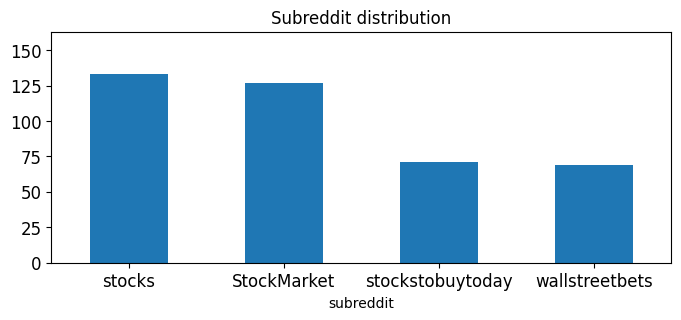

In [316]:
N_sample.subreddit.value_counts().plot(kind = 'bar',
                                       title = 'Subreddit distribution',
                                       ylim = [0, N_sample.subreddit.value_counts().max()+30], 
                                       rot = 0, fontsize = 12, figsize = (8,3))

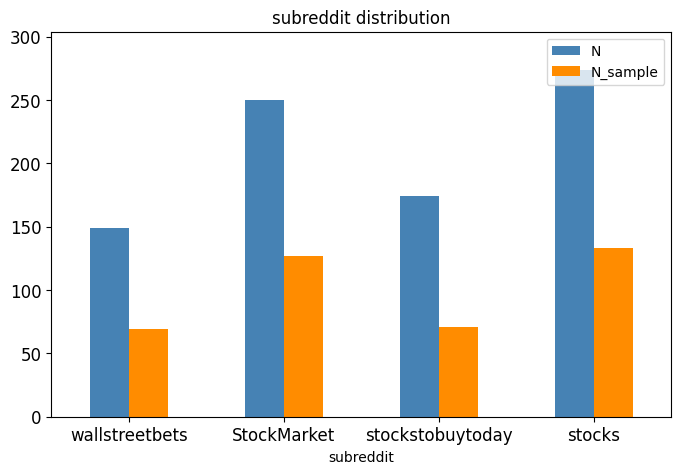

In [317]:
subreddit_order = N['subreddit'].unique()
counts_df = pd.DataFrame({
    'Full': N['subreddit'].value_counts().reindex(subreddit_order, fill_value=0),
    'Sample': N_sample['subreddit'].value_counts().reindex(subreddit_order, fill_value=0)
}).fillna(0)

ax = counts_df.plot(kind='bar', figsize=(8,5), rot=0, fontsize=12,color = ['steelblue','darkorange'])
plt.title('subreddit distribution')
plt.ylim(0, counts_df.values.max() + 30)  
ax.legend(['N', 'N_sample'], title="", loc="upper right")
plt.show()

## The different between analyze() and fit_transform → nonzero
analyze(N.text[0]) → What exact tokens (with duplicates) come out of preprocessing? 

fit_transform + nonzero → Which unique words from the vocabulary appear in this document?

In [318]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
analyze = count_vect.build_analyzer()
analyze(N.text[1])

['stunt',
 'as',
 'in',
 'like',
 'why',
 'did',
 'they',
 'even',
 'make',
 'big',
 'deal',
 'about',
 'starting',
 'it',
 'in',
 'the',
 'first',
 'place',
 'no',
 'company',
 'should',
 'ever',
 'talk',
 'about',
 'politics',
 'ever']

In [319]:
N_counts = count_vect.fit_transform(N.text) 
word_indices = N_counts[1].nonzero()[1]
word_in_doc = count_vect.get_feature_names_out()[word_indices]
print("The words that this 1 represents from the vocabulary are :\n",word_in_doc)

The words that this 1 represents from the vocabulary are :
 ['stunt' 'as' 'in' 'like' 'why' 'did' 'they' 'even' 'make' 'big' 'deal'
 'about' 'starting' 'it' 'the' 'first' 'place' 'no' 'company' 'should'
 'ever' 'talk' 'politics']


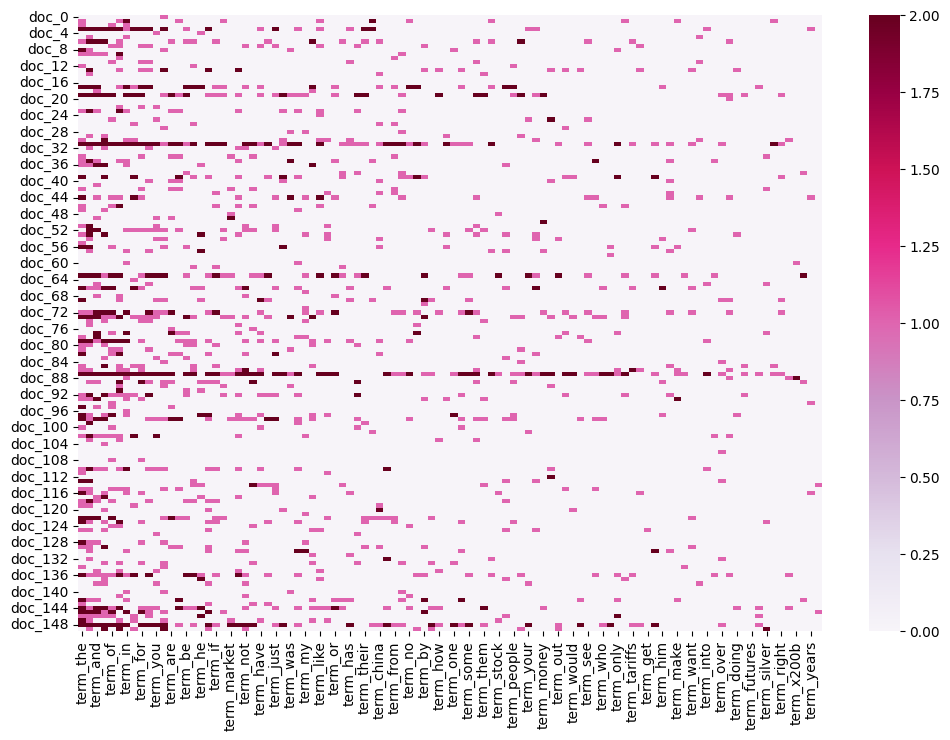

In [320]:
import seaborn as sns

# Number of documents and terms
docs = 150 
terms = 100 

#safety bounds 
n_docs, n_terms = N_counts.shape
docs  = min(docs,  n_docs)
terms = min(terms, n_terms)

# Top-N terms (efficient Top-K selection)
# sum over documents -> total frequency per term, return 1D array
term_sums = N_counts.sum(axis=0).A1
# get top-K indices in O(n) time, then sort those K by descending score
top_indices = np.argpartition(term_sums, -terms)[-terms:]
top_indices = top_indices[np.argsort(term_sums[top_indices])[::-1]]

# Rename the axis
plot_x = ["term_"+str(i) for i in count_vect.get_feature_names_out()[top_indices]]
plot_y = ["doc_"+str(i) for i in list(N.index)[:docs]]

# Create Submatrix
plot_z = N_counts[:docs, :][:, top_indices].toarray()

# DataFrame for Heatmap
df_todraw = pd.DataFrame(plot_z, columns=plot_x, index=plot_y)

# plot Heatmap 
plt.subplots(figsize=(12, 8))
ax = sns.heatmap(
    df_todraw,
    cmap="PuRd",
    vmin=0,
    vmax=np.percentile(plot_z, 99),  
    annot=False
)
plt.show()

In [321]:
import plotly.express as px

#compute the term frequency
term_counts = np.asarray(N_counts.sum(axis=0)).ravel()
feature_names = count_vect.get_feature_names_out()

#build dataframe
df = pd.DataFrame({"term": feature_names, "counts": term_counts})
df_top = df.sort_values("counts", ascending=False).head(300)

#plot horizontal bar chart
fig = px.bar(df_top.sort_values("counts"), 
             x="counts", y="term",
             orientation="h",
             title="Top 300 Term Frequencies")

fig.update_layout(yaxis=dict(autorange="reversed"))
fig.update_layout(height=1000)
fig.show()

In [322]:
import plotly.graph_objects as go

# Assume you already have df_top (Top 300 by frequency)
# Prepare: sort by frequency (desc) and create rank
df_plot = df_top.sort_values("counts", ascending=False).reset_index(drop=True)
df_plot["rank"] = np.arange(1, len(df_plot) + 1)

# 20% cutoff (k points)
k = max(1, int(np.ceil(0.2 * len(df_plot))))

fig = go.Figure()

# Yellow area for ALL points (bottom 80% + top 20% as base)
fig.add_trace(go.Scatter(
    x=df_plot["rank"], y=df_plot["counts"],
    mode="none", fill="tozeroy",
    fillcolor="rgba(255, 215, 0, 0.6)", 
    showlegend=False   # yellow
))

# Green area overlay for TOP 20% (leftmost k points)
fig.add_trace(go.Scatter(
    x=df_plot["rank"][:k], y=df_plot["counts"][:k],
    mode="none", fill="tozeroy",
    fillcolor="rgba(0, 160, 0, 0.7)",
    showlegend=False,     # green
))

fig.update_layout(
    title="Term Frequency ",
    xaxis_title="Terms",
    yaxis_title="Frequency",
    height=600,
    template="none"
)

fig.show()

## New Data Visualization
Observe how activity varies over time.

<module 'matplotlib.pyplot' from 'c:\\DM2025-Lab1\\DM2025-Lab1-Exercise\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

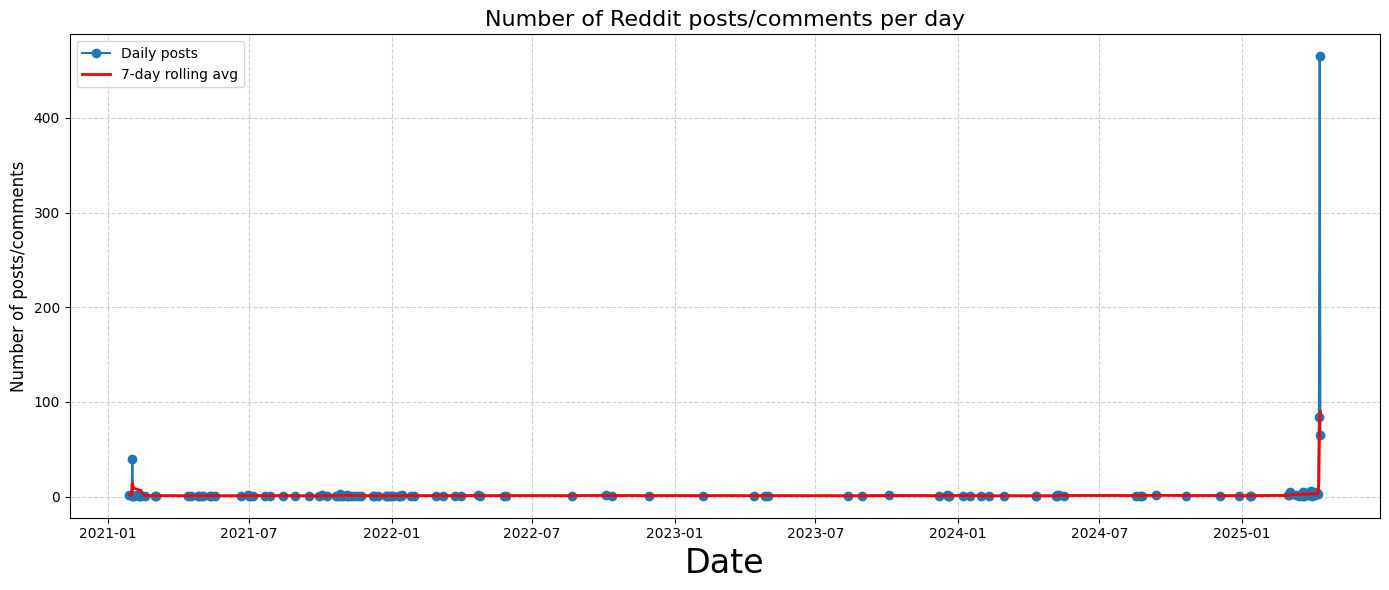

In [323]:
df = pd.read_csv('newdataset\Reddit-stock-sentiment.csv')
# Make sure the datetime column is parsed correctly
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Group by date to count posts per day
df['date'] = df['datetime'].dt.date
posts_per_day = df.groupby('date').size()

# Calculate 7-day rolling average 
rolling_avg = posts_per_day.rolling(window=7, min_periods=1).mean()

# Plot line chart
plt.figure(figsize=(14,6))

# Daily posts line
plt.plot(posts_per_day.index, posts_per_day.values, marker='o', linestyle='-', label="Daily posts")

# 7-day rolling average line
plt.plot(rolling_avg.index, rolling_avg.values, color='red', linewidth=2, label="7-day rolling avg")

# Titles and labels
plt.title("Number of Reddit posts/comments per day", fontsize=16)
plt.xlabel("Date", fontsize=24)
plt.ylabel("Number of posts/comments", fontsize=12)

# Add legend
plt.legend()

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt


# Phase 2

### Finding frquent patterns

check the context

In [324]:
label_map = {
    0.0: "zero",
    -1.0: "negative",
    1.0: "positive"
}
newData["label_name"] = newData["label"].map(label_map)
newData

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label,label_name
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0,negative
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0,zero
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0,zero
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0,positive
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didnât say thank you.,0.000000,0.000000,0.0,[],-1.0,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,comment,2021-06-30 4:06:06,h3iv6pq,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Ordinary-Office9180,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,Invest now it is going to shoot up tomorrow,0.000000,0.000000,0.0,['tomorrow'],1.0,positive
843,comment,2025-04-11 5:01:24,mmijiuz,StockMarket,$ U.S. dollar value (crashing),lulububudu,https://i.redd.it/atvlo83gk4ue1.jpeg,2,NaN,NaN,Where can I read this?,0.000000,0.000000,0.0,[],0.0,zero
844,post,2025-03-24 12:30:39,1jipi4v,stockstobuytoday,Analyst Recommendations,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,0.0,1.00,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.000000,0.000000,0.0,"['Analyst', 'Nasdaq', 'Stock', 'Upgrades', 'Do...",0.0,zero
845,comment,2025-04-11 20:13:26,mmmely7,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,yes_ur_wrong,https://www.reddit.com/r/wallstreetbets/commen...,10,NaN,NaN,i sold my puts so i expect cheeto to declare w...,0.000000,0.000000,0.0,"['war', 'denmark', 'cheeto', 'i']",-1.0,negative


In [325]:
### Begin Assignment Here
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

#Create separate DataFrames for each category
label_categories = newData['label'].unique()  # Get unique category labels(不重複)
category_dfs = {}  # Dictionary to store DataFrames for each category

for label in label_categories:
    # Filter the original DataFrame by category
    category_dfs[label] = newData[newData['label'] == label].copy()

# Function to create term-document frequency DataFrame for each category
def create_term_document_df(df):
    count_vect = CountVectorizer()  # Initialize the CountVectorizer
    X_counts = count_vect.fit_transform(df['text'])  # Transform the text data into word counts
    
    # Get the unique words (vocabulary) from the vectorizer
    words = count_vect.get_feature_names_out()
    
    # Create a DataFrame where rows are documents and columns are words
    term_document_df = pd.DataFrame(X_counts.toarray(), columns=words)
    
    return term_document_df

# Create term-document frequency DataFrames for each category
filt_term_document_dfs = {}  # Dictionary to store term-document DataFrames for each category

for label in label_categories:
    filt_term_document_dfs[label] = create_term_document_df(category_dfs[label])

In [326]:
# Display the filtered DataFrame for one of the categories, feel free to change the number in the vector
category_number=1 # You can change it from 0 to 2
print(f"Filtered Term-Document Frequency DataFrame for Category {label_categories[category_number]}:")
filt_term_document_dfs[label_categories[category_number]]

Filtered Term-Document Frequency DataFrame for Category 0.0:


,00,000,01378,027,08,10,100,100k,100x,10k,...,young,your,yours,yourself,youâ,yoyo,yup,zgld,zone,zsil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
419,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
420,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
421,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


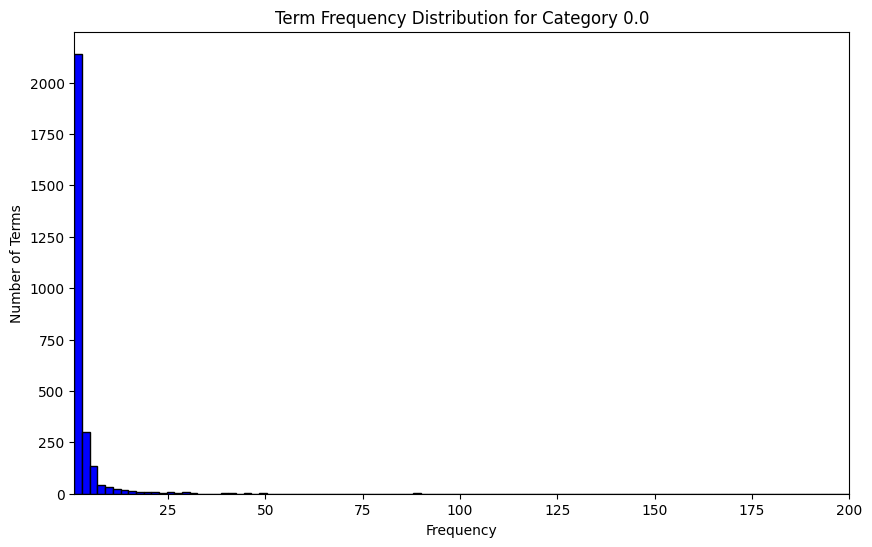

In [327]:
category_number=1 #You can change it from 0 to 2
word_counts = filt_term_document_dfs[label_categories[category_number]].sum(axis=0).to_numpy()
 
# Visualize the frequency distribution
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=200, color='blue', edgecolor='black')
plt.title(f'Term Frequency Distribution for Category {label_categories[category_number]}')
plt.xlabel('Frequency')
plt.ylabel('Number of Terms')
plt.xlim(1, 200)
plt.show()

### Filtering the top 5% and bottom 5% and Removing them

In [328]:
category_number=1 #You can change it from 0 to 3
word_counts = filt_term_document_dfs[label_categories[category_number]].sum(axis=0).to_numpy()

# Sort the term frequencies in descending order
sorted_indices = np.argsort(word_counts)[::-1]  # Get indices of sorted frequencies
sorted_counts = np.sort(word_counts)[::-1]  # Sort frequencies in descending order

# Calculate the index corresponding to the top 5% most frequent terms
total_terms = len(sorted_counts)
top_5_percent_index = int(0.05 * total_terms)

# Get the indices of the top 5% most frequent terms
top_5_percent_indices = sorted_indices[:top_5_percent_index]

# Filter terms that belong to the top 5% based on their rank
filtered_words = [filt_term_document_dfs[label_categories[category_number]].iloc[:, i].name for i in top_5_percent_indices]

print(f"Category: {label_categories[category_number]}")
print(f"Number of terms in top 5%: {top_5_percent_index}")
print(f"Filtered terms: {filtered_words}")


Category: 0.0
Number of terms in top 5%: 139
Filtered terms: ['the', 'to', 'and', 'is', 'of', 'it', 'in', 'that', 'for', 'this', 'you', 'on', 'market', 'are', 'they', 'if', 'with', 'as', 'be', 'not', 'my', 'was', 'like', 'but', 'or', 'at', 'all', 'stock', 'so', 'what', 'have', 'just', 'about', 'us', 'from', 'he', 'will', 'do', 'by', 'your', 'how', 'futures', 'can', 'price', 'no', 'we', 'now', 'there', 're', 'any', 'more', 'up', 'their', 'has', 'x200b', 'an', 'some', 'one', 'trump', 'company', 'want', 'why', 'see', 'china', 'com', 'them', 'even', 'stockbuyvest', 'who', 'people', 'would', 'money', 'were', 'out', 'when', 'into', 'stocks', 'think', 'good', 'year', 'does', 'going', 'me', 'did', 'only', 'first', 'been', '10', 'than', 'could', 'today', 'right', 'other', 'years', 'its', 'new', 'silver', 'then', 'tariffs', 'know', 'always', 'get', 'iâ', 'daily', 'call', 'may', 'time', 'over', 'too', 'also', 'updated', 'investors', 'here', 'should', 'day', 'itâ', 'after', 'because', 'before', 'o

In [329]:
category_number=1 #You can change it from 0 to 3
word_counts = filt_term_document_dfs[label_categories[category_number]].sum(axis=0).to_numpy()

# Sort the term frequencies in ascending order and get sorted indices
sorted_indices = np.argsort(word_counts)  # Get indices of sorted frequencies
sorted_counts = word_counts[sorted_indices]  # Sort frequencies

# Calculate the index corresponding to the bottom 1% least frequent terms
total_terms = len(sorted_counts)
bottom_1_percent_index = int(0.01 * total_terms)

# Get the indices of the bottom 1% least frequent terms
bottom_1_percent_indices = sorted_indices[:bottom_1_percent_index]

# Filter terms that belong to the bottom 1% based on their rank
filtered_words = [filt_term_document_dfs[label_categories[category_number]].iloc[:, i].name for i in bottom_1_percent_indices]

print(f"Category: {label_categories[category_number]}")
print(f"Number of terms in bottom 1%: {bottom_1_percent_index}")
print(f"Filtered terms: {filtered_words}")


Category: 0.0
Number of terms in bottom 1%: 27
Filtered terms: ['17th', '18', '186', '18630', '1870', '1k', '1m', '118', '1242', 'opinion', 'opportunities', 'opportunity', 'opposed', 'options', 'officer', 'official', '2012', '01378', '027', '08', '100k', '100x', '15m', '12855584', '14', '140', '145']


overlook the bottom 1% and top 5% words

In [330]:
category_number=1 #You can change it from 0 to 2

# Filter the bottom 1% and top 5% words based on their sum across all documents
def filter_top_bottom_words_by_sum(term_document_df, top_percent=0.05, bottom_percent=0.01):
    # Calculate the sum of each word across all documents
    word_sums = term_document_df.sum(axis=0)
    
    # Sort the words by their total sum
    sorted_words = word_sums.sort_values()
    
    # Calculate the number of words to remove
    total_words = len(sorted_words)
    top_n = int(top_percent * total_words)
    bottom_n = int(bottom_percent * total_words)
    
    # Get the words to remove from the top 5% and bottom 5%
    words_to_remove = pd.concat([sorted_words.head(bottom_n), sorted_words.tail(top_n)]).index
    print(f'Bottom {bottom_percent*100}% words: \n{sorted_words.head(bottom_n)}') #Here we print which words correspond to the bottom percentage we filter
    print(f'Top {top_percent*100}% words: \n{sorted_words.tail(top_n)}') #Here we print which words correspond to the top percentage we filter
    # Return the DataFrame without the filtered words
    return term_document_df.drop(columns=words_to_remove)

# Apply the filtering function to each category
term_document_dfs = {}

for category in label_categories:
    print(f'\nFor category {category} we filter the following words:')
    term_document_dfs[category] = filter_top_bottom_words_by_sum(filt_term_document_dfs[category])

# Example: Display the filtered DataFrame for one of the categories
print(f"Filtered Term-Document Frequency DataFrame for Category {label_categories[category_number]}:")
term_document_dfs[label_categories[category_number]]



For category -1.0 we filter the following words:
Bottom 1.0% words: 
1974           1
13â            1
13             1
10000          1
1000           1
selloff        1
self           1
42             1
401k           1
40             1
350            1
31             1
operational    1
operate        1
open           1
onto           1
4th            1
17th           1
160            1
16             1
150            1
14th           1
dtype: int64
Top 5.0% words: 
shit       11
bad        11
dollar     11
after      11
iâ         11
         ... 
of        130
is        178
and       193
to        231
the       409
Length: 111, dtype: int64

For category 0.0 we filter the following words:
Bottom 1.0% words: 
17th             1
18               1
186              1
18630            1
1870             1
1k               1
1m               1
118              1
1242             1
opinion          1
opportunities    1
opportunity      1
opposed          1
options          1
officer    

,00,000,100,10k,10ks,10yr,11,12,125,15,...,yields,young,yours,yourself,youâ,yoyo,yup,zgld,zone,zsil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
419,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
420,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
421,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [331]:
'''
In the label index, the Top 5% words are highly similar, mostly consisting of common conjunctions and function words (such as it, and, of, the, and that).
In contrast, the Bottom 1% words show clear differences among the indexes, mainly composed of numerical strings. 
The Top 5% pattern aligns with the findings from the Lab 1 Master exercise, whereas the Bottom 1% pattern differs—likely. 
Because the Master dataset is based on news articles, which include place names and uncommon nouns,
while the homework dataset comes from stock forums, where the frequent presence of numbers is expected.
'''

'\nIn the label index, the Top 5% words are highly similar, mostly consisting of common conjunctions and function words (such as it, and, of, the, and that).\nIn contrast, the Bottom 1% words show clear differences among the indexes, mainly composed of numerical strings. \nThe Top 5% pattern aligns with the findings from the Lab 1 Master exercise, whereas the Bottom 1% pattern differs—likely. \nBecause the Master dataset is based on news articles, which include place names and uncommon nouns,\nwhile the homework dataset comes from stock forums, where the frequent presence of numbers is expected.\n'

###  Convert dataframe into a transactional database

In [332]:
import builtins

_orig_open = open

def safe_open(*args, **kwargs):
    if len(args) > 0 and isinstance(args[0], str) and args[0].endswith('.csv'):
        kwargs['encoding'] = 'latin-1'   # Force Latin-1
        kwargs['errors'] = 'ignore'      # Ignore bad characters
    return _orig_open(*args, **kwargs)


builtins.open = safe_open

In [333]:
from PAMI.extras.convert.DF2DB import DF2DB            

# Loop through the dictionary of term-document DataFrames
for category in term_document_dfs:
    # Replace dots with underscores in the category name to avoid errors in the file creation
    category_safe = str(category).replace('.', '_') # need to tranfer category to str(category)
    
    # Create the DenseFormatDF object and convert to a transactional database
    obj = DF2DB(term_document_dfs[category])           
        
    obj.convert2TransactionalDatabase(f'td_freq_db_{category_safe}.csv', '>=', 1)


Database size (total no of transactions) : 314
Number of items : 2095
Minimum Transaction Size : 1
Average Transaction Size : 12.012738853503185
Maximum Transaction Size : 138
Standard Deviation Transaction Size : 13.363600749152823
Variance in Transaction Sizes : 179.15638672391688
Sparsity : 0.9942659957739841


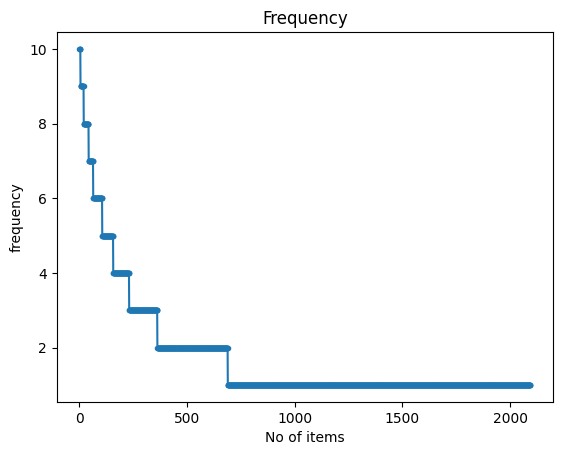

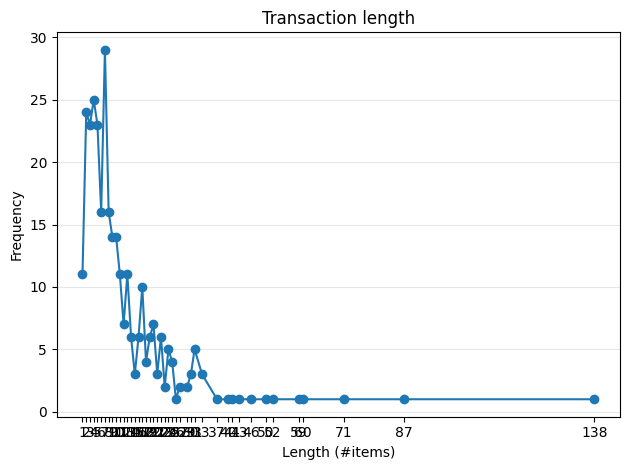

In [334]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_-1_0.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 417
Number of items : 2618
Minimum Transaction Size : 1
Average Transaction Size : 10.856115107913668
Maximum Transaction Size : 200
Standard Deviation Transaction Size : 18.28389017861048
Variance in Transaction Sizes : 335.1042473713337
Sparsity : 0.9958532791795593


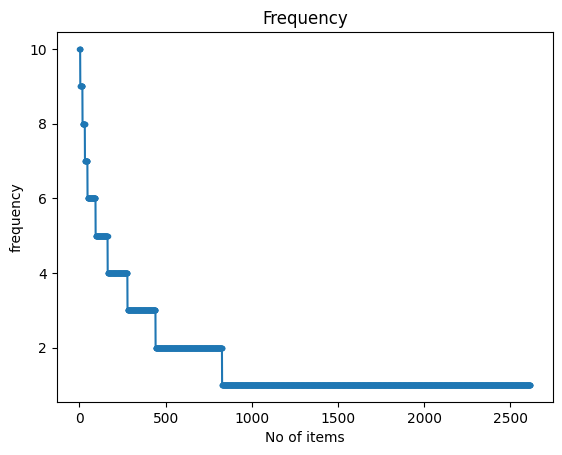

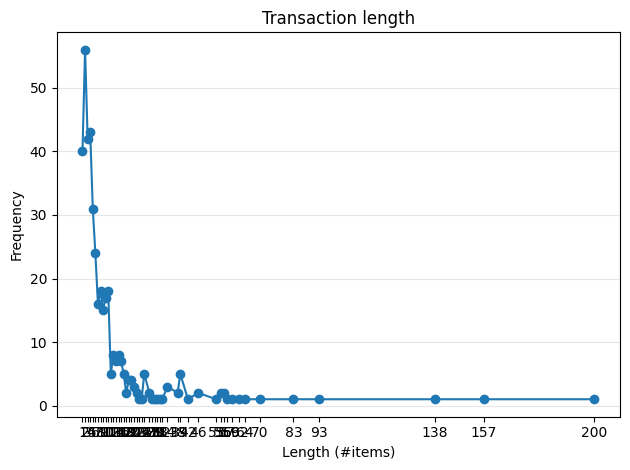

In [335]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_0_0.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 108
Number of items : 1116
Minimum Transaction Size : 1
Average Transaction Size : 14.407407407407407
Maximum Transaction Size : 92
Standard Deviation Transaction Size : 16.856165504072564
Variance in Transaction Sizes : 286.78573901003807
Sparsity : 0.9870901367317138


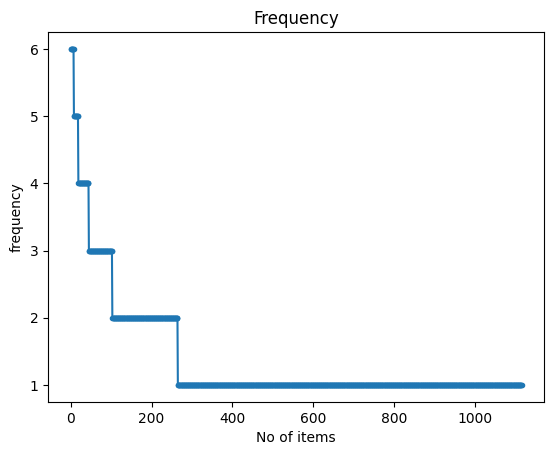

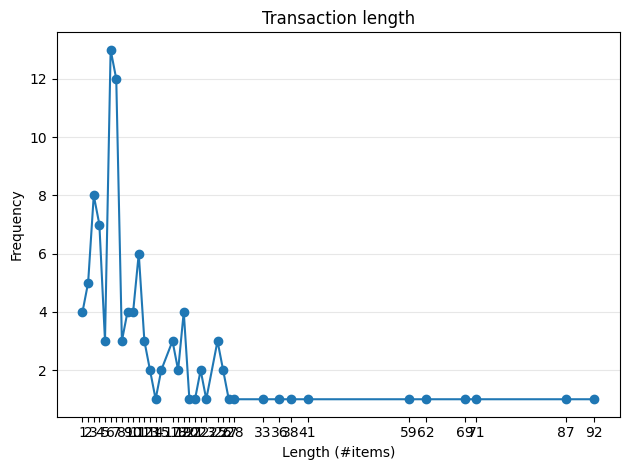

In [336]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_1_0.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

According to Figure 1 in td_freq_db_1_0.csv, we can see that if we set minSup at 9, too few items would be included since most appear less than ten times. Therefore, I chose minSup = 6 to keep a balance — it filters out very rare items but still captures meaningful and moderately frequent patterns in the data.

In [337]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj1 = alg.FPGrowth(iFile='td_freq_db_-1_0.csv', minSup=minSup)
obj1.mine()
frequentPatternsDF_index1 = obj1.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_index1 ))) #print the total number of patterns
print('Runtime: ' + str(obj1.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 106
Runtime: 0.0020067691802978516


In [338]:
import io

seperator = ' ' 

output_filename = 'freq_patterns_-1_0_minSup6.txt' 

print(f"Saving patterns from obj1 to {output_filename} using UTF-8...")

try:
    with io.open(output_filename, 'w', encoding='utf-8') as f:
        for x, y in obj1._finalPatterns.items(): 
            pattern_str = seperator.join(x)
            f.write(f"{pattern_str}:{y}\n")
            
    print("Successfully saved.")

except Exception as e:
    print(f"An error occurred: {e}")

frequentPatternsDF_index1

Saving patterns from obj1 to freq_patterns_-1_0_minSup6.txt using UTF-8...
Successfully saved.


,Patterns,Support
0,calls,6
1,companies,6
2,lot,6
3,next,6
4,first,6
...,...,...
101,things,10
102,here,10
103,these,10
104,sure,10


In [339]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj2 = alg.FPGrowth(iFile='td_freq_db_0_0.csv', minSup=minSup)
obj2.mine()
frequentPatternsDF_index2 = obj2.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_index2 ))) #print the total number of patterns
print('Runtime: ' + str(obj2.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 98
Runtime: 0.005149126052856445


In [340]:
obj2.save('freq_patterns_0_0_minSup6.txt') #save the patterns
frequentPatternsDF_index2

,Patterns,Support
0,big,6
1,deal,6
2,talk,6
3,months,6
4,probably,6
...,...,...
93,down,10
94,most,10
95,go,10
96,well,10


In [341]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj3 = alg.FPGrowth(iFile='td_freq_db_1_0.csv', minSup=minSup)
obj3.mine()
frequentPatternsDF_index3 = obj3.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_index3 ))) #print the total number of patterns
print('Runtime: ' + str(obj3.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 8
Runtime: 0.0016853809356689453


In [342]:
import io

seperator = ' ' 

output_filename = 'freq_patterns_1_0_minSup6.txt' 

print(f"Saving patterns from obj1 to {output_filename} using UTF-8...")

try:
    with io.open(output_filename, 'w', encoding='utf-8') as f:
        for x, y in obj3._finalPatterns.items(): 
            pattern_str = seperator.join(x)
            f.write(f"{pattern_str}:{y}\n")
            
    print("Successfully saved.")

except Exception as e:
    print(f"An error occurred: {e}")

frequentPatternsDF_index3

Saving patterns from obj1 to freq_patterns_1_0_minSup6.txt using UTF-8...
Successfully saved.


,Patterns,Support
0,into,6
1,your,6
2,us,6
3,them,6
4,itâ,6
5,out,6
6,economy,6
7,way,6


Now, I focus on unique patterns because they provide distinct, category-specific signals that improve the model’s ability to classify documents accurately.

In [343]:
import pandas as pd

#We group together all of the dataframes related to our found patterns
dfs = [frequentPatternsDF_index1, frequentPatternsDF_index2, frequentPatternsDF_index3]

# Identify patterns that appear in more than one category
# Count how many times each pattern appears across all dataframes
pattern_counts = {}
for df in dfs:
    for pattern in df['Patterns']:
        if pattern not in pattern_counts:
            pattern_counts[pattern] = 1
        else:
            pattern_counts[pattern] += 1

# Filter out patterns that appear in more than one dataframe
unique_patterns = {pattern for pattern, count in pattern_counts.items() if count == 1}
# Calculate the total number of patterns across all categories
total_patterns_count = sum(len(df) for df in dfs)
# Calculate how many patterns were discarded
discarded_patterns_count = total_patterns_count - len(unique_patterns)

# For each category, filter the patterns to keep only the unique ones
filtered_dfs = []
for df in dfs:
    filtered_df = df[df['Patterns'].isin(unique_patterns)]
    filtered_dfs.append(filtered_df)

# Merge the filtered dataframes into a final dataframe
final_pattern_df = pd.concat(filtered_dfs, ignore_index=True)

# Sort by support
final_pattern_df = final_pattern_df.sort_values(by='Support', ascending=False)

# Display the final result
print(final_pattern_df)
# Print the number of discarded patterns
print(f"Number of patterns discarded: {discarded_patterns_count}")

    Patterns  Support
84     again       10
159     down       10
160     most       10
162      his       10
161       go       10
..       ...      ...
164       us        6
165     them        6
166      itâ        6
167      out        6
168  economy        6

[169 rows x 2 columns]
Number of patterns discarded: 43


In [344]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Convert 'text' column into term-document matrix using CountVectorizer
count_vect = CountVectorizer()
X_tdm = count_vect.fit_transform(newData['text'])  # X['text'] contains your text data
terms = count_vect.get_feature_names_out()  # Original terms in the vocabulary

# Tokenize the sentences into sets of unique words
newData['tokenized_text'] = newData['text'].str.split().apply(set)

# Initialize the pattern matrix
pattern_matrix = pd.DataFrame(0, index=newData.index, columns=final_pattern_df['Patterns'])

# Iterate over each pattern and check if all words in the pattern are present in the tokenized sentence
for pattern in final_pattern_df['Patterns']:
    pattern_words = set(pattern.split())  # Tokenize pattern into words
    pattern_matrix[pattern] = newData['tokenized_text'].apply(lambda x: 1 if pattern_words.issubset(x) else 0)

# Convert the term-document matrix to a DataFrame for easy merging
tdm_df = pd.DataFrame(X_tdm.toarray(), columns=terms, index=newData.index)

# Concatenate the original TDM and the pattern matrix to augment the features
augmented_df = pd.concat([tdm_df, pattern_matrix], axis=1)

augmented_df

,00,000,01378,02,027,03,06,08,10,100,...,report,future,sense,trends,your,us,them,itâ,out,economy
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
844,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
845,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Implement the FAE Top-K and MaxFPGrowth algorithms

In [345]:
from PAMI.frequentPattern.topk import FAE as alg

for k in [200, 400, 600]:
    obj = alg.FAE(iFile='td_freq_db_-1_0.csv', k=k)
    obj.mine()
    patterns_df = obj.getPatternsAsDataFrame()
    print(f'\nFAE Top-K (k={k})')
    print('Total N0 of patterns: ' + str(len(patterns_df)))
    print('Runtime: ' + str(obj.getRuntime()))

 TopK frequent patterns were successfully generated using FAE algorithm.

FAE Top-K (k=200)
Total N0 of patterns: 200
Runtime: 0.008462667465209961
 TopK frequent patterns were successfully generated using FAE algorithm.

FAE Top-K (k=400)
Total N0 of patterns: 400
Runtime: 0.07253527641296387
 TopK frequent patterns were successfully generated using FAE algorithm.

FAE Top-K (k=600)
Total N0 of patterns: 600
Runtime: 0.12758827209472656


Compared to the Master exercise 17, setting k = 1000 resulted in a much longer runtime, likely due to the high sparsity of the data.

In [346]:
# Answer Here
from PAMI.frequentPattern.maximal import MaxFPGrowth  as alg 
inputFile = 'td_freq_db_comp_graphics.csv'

minSups=[4, 5, 6]

separator='\t'
for minSup in minSups:
    obj = alg.MaxFPGrowth(iFile=inputFile, minSup=minSup, sep=separator)    
    obj.mine()         
    frequentPatternsDF= obj.getPatternsAsDataFrame()
    print('Total No of patterns: ' + str(len(frequentPatternsDF)))
    print('Runtime: ' + str(obj.getRuntime()))
    obj.save(outFile=f'-1_0_maximal_minsup{minSup}.txt')

Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 4399
Runtime: 1.0184249877929688
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 2189
Runtime: 0.5836515426635742
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 1347
Runtime: 0.19019508361816406


### Dimensionality Reduction

c:\DM2025-Lab1\DM2025-Lab1-Exercise\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



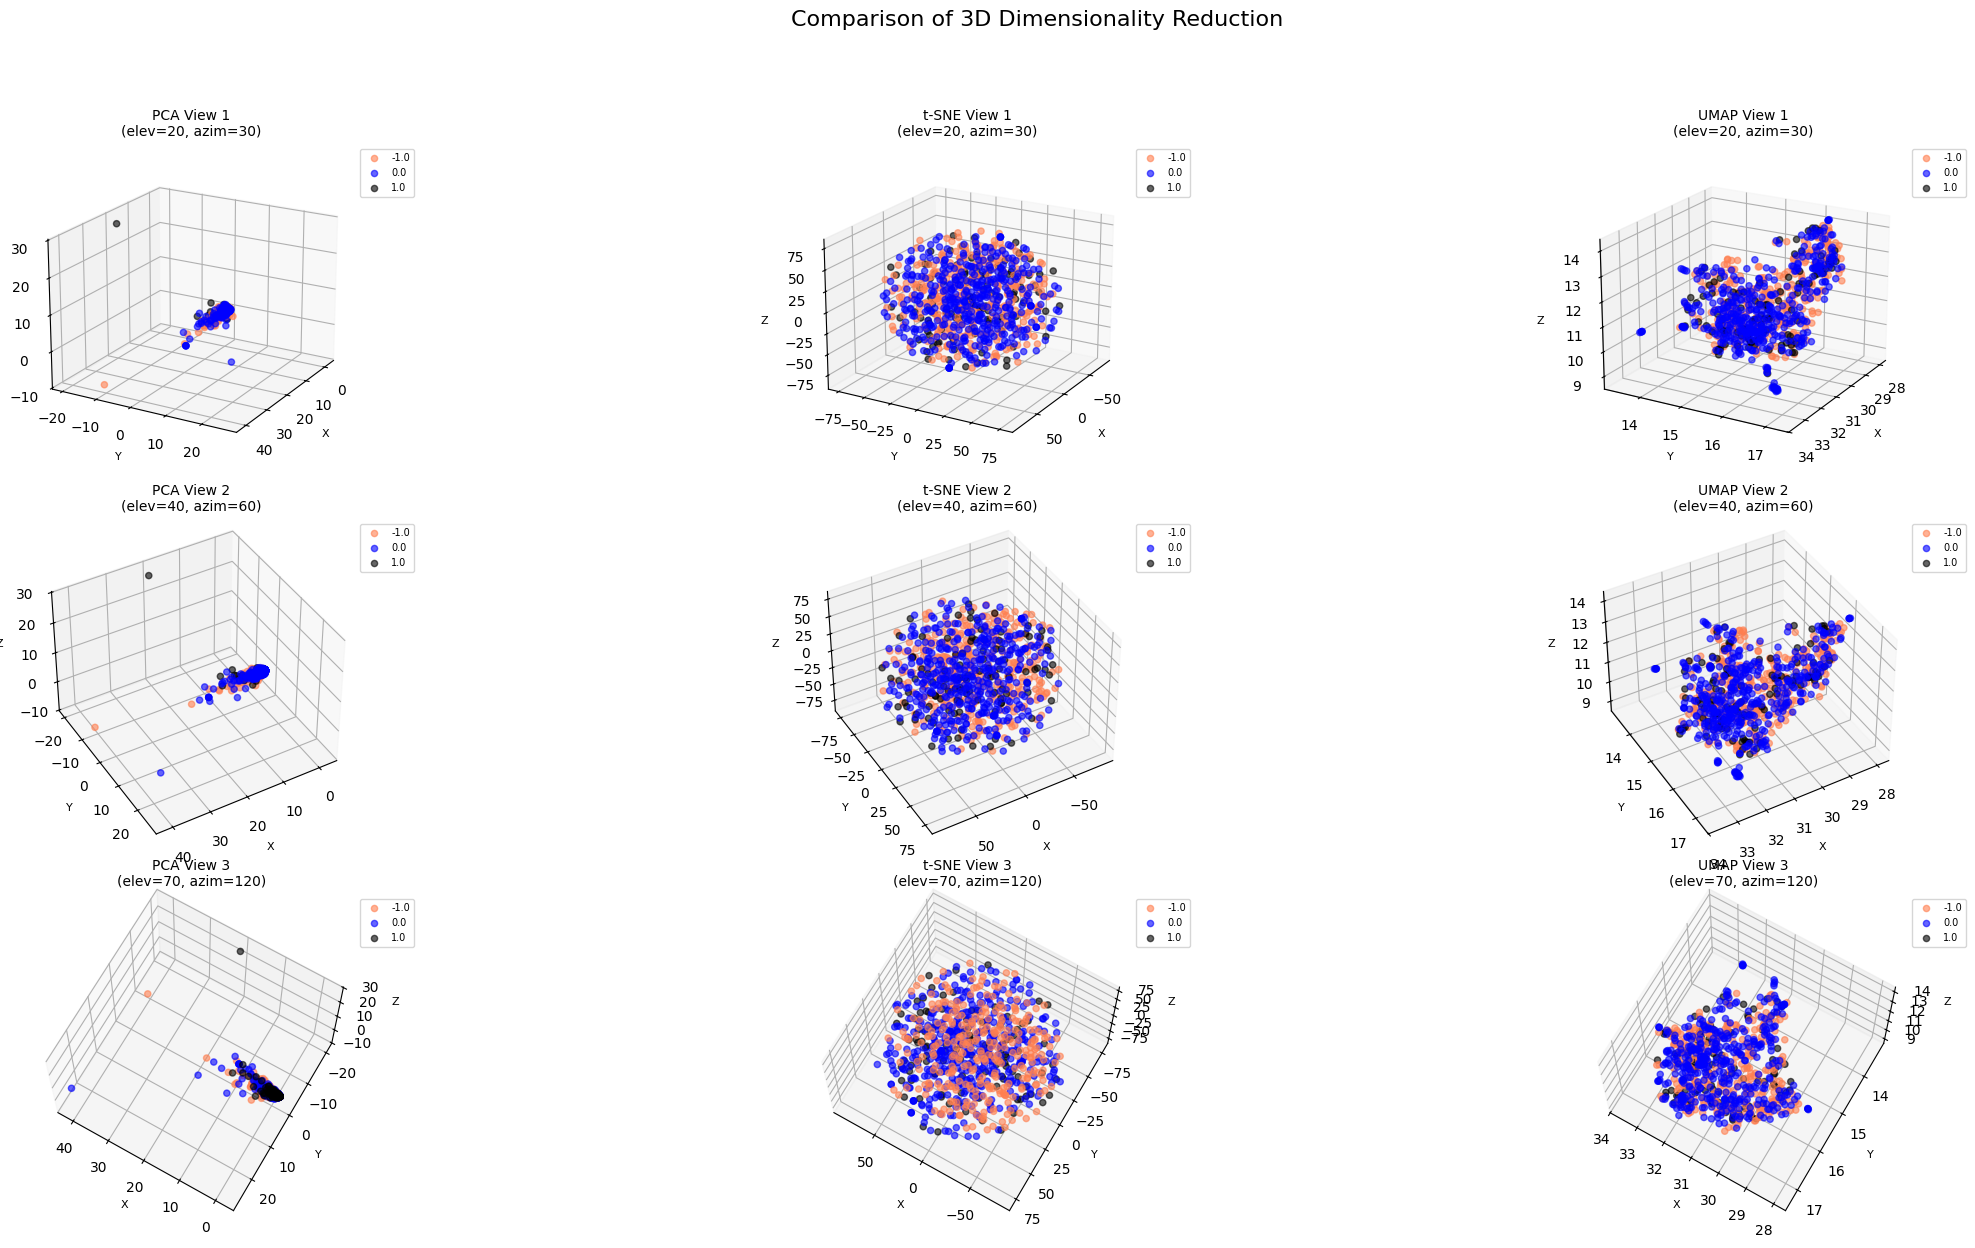

In [347]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# reduce the dimension to 3
X_pca_3d = PCA(n_components=3).fit_transform(tdm_df.values)
X_tsne_3d = TSNE(n_components=3, random_state=42).fit_transform(tdm_df.values)
X_umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(tdm_df.values)

# set up the color
col = ['coral', 'blue', 'black', 'orange']
categories = newData['label'].unique()

# plot 3D 
def plot_3d(ax, X_reduced, title, elev, azim):
    for c, category in zip(col, categories):
        mask = newData['label'] == category
        ax.scatter(X_reduced[mask, 0],
                   X_reduced[mask, 1],
                   X_reduced[mask, 2],
                   c=c, label=category, alpha=0.6)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f'{title}\n(elev={elev}, azim={azim})', fontsize=10)
    ax.set_xlabel('X', fontsize=8) 
    ax.set_ylabel('Y', fontsize=8)
    ax.set_zlabel('Z', fontsize=8)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=7)

fig = plt.figure(figsize=(28, 12))
angles = [(20, 30), (40, 60), (70, 120)]  
reduction_methods = {'PCA': X_pca_3d, 't-SNE': X_tsne_3d, 'UMAP': X_umap_3d}
method_names = ['PCA', 't-SNE', 'UMAP']

for col_idx, method_name in enumerate(method_names):
    X_reduced = reduction_methods[method_name]
    for row_idx, (elev, azim) in enumerate(angles):
        ax = fig.add_subplot(len(angles), len(method_names), 3 * row_idx + col_idx + 1, projection='3d')
        plot_3d(ax, X_reduced, f'{method_name} View {row_idx+1}', elev, azim)

plt.tight_layout(rect=[0, 0, 0.95, 0.95]) 

fig.suptitle('Comparison of 3D Dimensionality Reduction', fontsize=16, y=1.02) 

plt.show()

### Discretization and Binarization

In [348]:
from sklearn import preprocessing, metrics, decomposition, pipeline, dummy
mlb = preprocessing.LabelBinarizer()
mlb.fit(newData.label)
newData['bin_label'] = mlb.transform(newData['label']).tolist()
newData[0:9]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label,label_name,tokenized_text,bin_label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0,negative,"{retards, Calls, on}","[1, 0, 0]"
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0,zero,"{in, like, company, place?, talk, first, about...","[0, 1, 0]"
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0,zero,"{ticker., in, red, Seeing, of, lots, the}","[0, 1, 0]"
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0,positive,"{years, This, Power, have, highlights, ruleboo...","[0, 0, 1]"
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didnât say thank you.,0.000000,0.000000,0.0,[],-1.0,negative,"{thank, didnât, you., He, say}","[1, 0, 0]"
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0,zero,"{in, luck, me, wish, warm, wet, to, puss, ejac...","[0, 1, 0]"
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0,negative,"{respond, tariffs., LOT, increasing, is, all, ...","[1, 0, 0]"
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0,zero,"{like, 2, let, trap., word, for, of, have, bee...","[0, 1, 0]"
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0,positive,"{one, held, on, line, pivot, seeing, handle, f...","[0, 0, 1]"


### Data Exploration

In [349]:
from sklearn.metrics.pairwise import cosine_similarity
document_test_1 = []
document_test_1.append(newData.iloc[1]['text'])  

document_test_2 = []
document_test_2.append(newData.iloc[2]['text'])  

document_test_3 = []
document_test_3.append(newData.iloc[7]['text'])  

doc_vec_1 = count_vect.transform(document_test_1)
doc_vec_2 = count_vect.transform(document_test_2)
doc_vec_3 = count_vect.transform(document_test_3)

print(f"Doc 1 category: {newData.iloc[1]['label']}")
print(f"Doc 2 category: {newData.iloc[2]['label']}")
print(f"Doc 3 category: {newData.iloc[7]['label']}")

cos_sim_1_2 = cosine_similarity(doc_vec_1, doc_vec_2, dense_output=True)
cos_sim_1_3 = cosine_similarity(doc_vec_1, doc_vec_3, dense_output=True)
cos_sim_2_3 = cosine_similarity(doc_vec_2, doc_vec_3, dense_output=True)

print("Cosine Similarity using count bw 1 and 2: %(x)f" %{"x":cos_sim_1_2})
print("Cosine Similarity using count bw 1 and 3: %(x)f" %{"x":cos_sim_1_3})
print("Cosine Similarity using count bw 2 and 3: %(x)f" %{"x":cos_sim_2_3})

Doc 1 category: 0.0
Doc 2 category: 0.0
Doc 3 category: 0.0
Cosine Similarity using count bw 1 and 2: 0.200446
Cosine Similarity using count bw 1 and 3: 0.077152
Cosine Similarity using count bw 2 and 3: 0.082479


C:\Users\user\AppData\Local\Temp\ipykernel_27636\3439925303.py:23: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\user\AppData\Local\Temp\ipykernel_27636\3439925303.py:24: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\user\AppData\Local\Temp\ipykernel_27636\3439925303.py:25: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



### Data classification

In [350]:
#Model with only the document-term frequency data
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Create a mapping from numerical labels to category names
category_mapping = dict(newData[['label','label_name']].drop_duplicates().values)

# Convert the numerical category labels to text labels
target_names = [category_mapping[label] for label in sorted(category_mapping.keys())]

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(tdm_df, newData['label'], test_size=0.3, random_state=42)

In [351]:
X_train

,00,000,01378,02,027,03,06,08,10,100,...,yourself,yourselves,youtube,youâ,yoyo,yup,zero,zgld,zone,zsil
739,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
140,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
173,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
552,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
106,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
270,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [352]:
X_test

,00,000,01378,02,027,03,06,08,10,100,...,yourself,yourselves,youtube,youâ,yoyo,yup,zero,zgld,zone,zsil
457,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
342,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
280,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
275,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
548,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
351,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
136,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [353]:
# Train the Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

Accuracy: 0.5843137254901961

Classification Report:
               precision    recall  f1-score   support

    negative     0.5820    0.7245    0.6455        98
        zero     0.6210    0.6364    0.6286       121
    positive     0.1111    0.0278    0.0444        36

    accuracy                         0.5843       255
   macro avg     0.4380    0.4629    0.4395       255
weighted avg     0.5340    0.5843    0.5526       255



In [354]:
# Split the augmented data into training and testing sets (70% train, 30% test)
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(augmented_df, newData['label'], test_size=0.3, random_state=42)

# Train the Naive Bayes classifier 
nb_classifier_aug = MultinomialNB()
nb_classifier_aug.fit(X_train_aug, y_train_aug)

# Make predictions on the test set
y_pred_aug = nb_classifier_aug.predict(X_test_aug)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test_aug, y_pred_aug))
print("\nClassification Report:\n", classification_report(y_test_aug, y_pred_aug, target_names=target_names, digits=4))

Accuracy: 0.596078431372549

Classification Report:
               precision    recall  f1-score   support

    negative     0.6000    0.7347    0.6606        98
        zero     0.6320    0.6529    0.6423       121
    positive     0.1000    0.0278    0.0435        36

    accuracy                         0.5961       255
   macro avg     0.4440    0.4718    0.4488       255
weighted avg     0.5446    0.5961    0.5648       255



### Decision Tree Classifier

In [355]:
# Decision Tree with only the document-term frequency data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split the data (already done above, but shown here for clarity)
X_train, X_test, y_train, y_test = train_test_split(tdm_df, newData['label'], test_size=0.3, random_state=42)

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (TDM): 0.5411764705882353

Classification Report:
               precision    recall  f1-score   support

    negative     0.5301    0.4490    0.4862        98
        zero     0.5789    0.7273    0.6447       121
    positive     0.3000    0.1667    0.2143        36

    accuracy                         0.5412       255
   macro avg     0.4697    0.4476    0.4484       255
weighted avg     0.5208    0.5412    0.5230       255



In [356]:
#Answer
X_train, X_test, y_train, y_test = train_test_split(augmented_df, newData['label'], test_size=0.3, random_state=42)

# Train Decision Tree
dt_classifier_aug = DecisionTreeClassifier(random_state=42)
dt_classifier_aug.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_classifier_aug.predict(X_test)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))


Decision Tree Accuracy (TDM): 0.5254901960784314

Classification Report:
               precision    recall  f1-score   support

    negative     0.5125    0.4184    0.4607        98
        zero     0.5404    0.7190    0.6170       121
    positive     0.4286    0.1667    0.2400        36

    accuracy                         0.5255       255
   macro avg     0.4938    0.4347    0.4392       255
weighted avg     0.5139    0.5255    0.5037       255

